✅ Solvable map generated on attempt 2
Map Size: 15x15
Start: (0, 0), End: (14, 14)
Obstacles: 67
✅ Path found! Length: 31 steps.


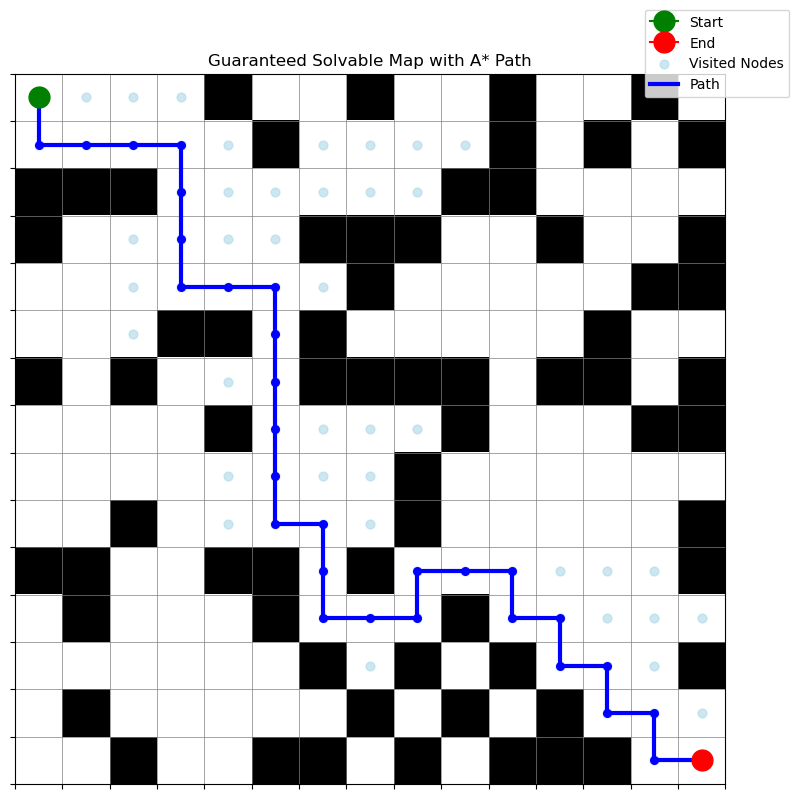

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import heapq
from collections import deque
import random

class PathPlanningEnv:
    def __init__(self, width=15, height=15, obstacle_ratio=0.3, max_retries=100):
        """Initialize the path planning environment with guaranteed solvability."""
        self.width = width
        self.height = height
        self.obstacle_ratio = obstacle_ratio
        self.max_retries = max_retries

        self.grid = None
        self.start = None
        self.end = None

        # Try to generate a solvable map
        for attempt in range(max_retries):
            self._generate_obstacles()
            self._set_start_end()
            if self._is_solvable():
                print(f"✅ Solvable map generated on attempt {attempt + 1}")
                return
        
        raise RuntimeError(f"Failed to generate a solvable map after {max_retries} attempts. Try reducing obstacle_ratio.")

    def _generate_obstacles(self):
        """Randomly generate obstacles."""
        self.grid = np.zeros((self.height, self.width), dtype=int)
        num_cells = self.width * self.height
        num_obstacles = int(num_cells * self.obstacle_ratio)
        count = 0
        while count < num_obstacles:
            x = np.random.randint(0, self.width)
            y = np.random.randint(0, self.height)
            if self.grid[y, x] == 0:
                self.grid[y, x] = 1
                count += 1

    def _set_start_end(self):
        """Set start and end points."""
        found_start = False
        found_end = False

        # Find Start (Top-Left)
        for y in range(self.height):
            for x in range(self.width):
                if self.grid[y, x] == 0:
                    self.start = (x, y)
                    found_start = True
                    break
            if found_start:
                break

        # Find End (Bottom-Right)
        for y in range(self.height - 1, -1, -1):
            for x in range(self.width - 1, -1, -1):
                if self.grid[y, x] == 0 and (x, y) != self.start:
                    self.end = (x, y)
                    found_end = True
                    break
            if found_end:
                break

        if not found_start or not found_end:
            raise ValueError("Too many obstacles, unable to set start and end points.")

    def _is_solvable(self):
        """Check if there's any path from start to end using BFS."""
        if self.start is None or self.end is None:
            return False
        
        queue = deque([self.start])
        visited = {self.start}
        
        while queue:
            x, y = queue.popleft()
            if (x, y) == self.end:
                return True
            
            for dx, dy in [(0,1), (0,-1), (1,0), (-1,0)]:
                nx, ny = x + dx, y + dy
                if (0 <= nx < self.width and 0 <= ny < self.height 
                    and self.grid[ny, nx] == 0 and (nx, ny) not in visited):
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        
        return False

    def get_neighbors(self, node):
        """Get valid neighbors (Up, Down, Left, Right)."""
        x, y = node
        neighbors = []
        directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < self.width and 0 <= ny < self.height and self.grid[ny, nx] == 0:
                neighbors.append((nx, ny))
        return neighbors

    def _heuristic(self, node, goal):
        """Calculate Manhattan distance heuristic."""
        x1, y1 = node
        x2, y2 = goal
        return abs(x1 - x2) + abs(y1 - y2)

    def solve_a_star(self):
        """Integrated A* Algorithm."""
        if self.start is None or self.end is None:
            raise ValueError("Start or End point not defined.")

        start = self.start
        goal = self.end

        open_set = []
        heapq.heappush(open_set, (0, 0, start))
        
        came_from = {}
        g_score = {start: 0}
        f_score = {start: self._heuristic(start, goal)}
        
        visited = set()
        counter = 1

        while open_set:
            _, _, current = heapq.heappop(open_set)

            if current == goal:
                path = [current]
                while current in came_from:
                    current = came_from[current]
                    path.append(current)
                path.reverse()
                return path, visited

            visited.add(current)

            for neighbor in self.get_neighbors(current):
                if neighbor in visited:
                    continue

                tentative_g = g_score[current] + 1

                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self._heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], counter, neighbor))
                    counter += 1

        return None, visited

    def plot_map(self, path=None, visited_nodes=None, title='Path Planning Environment'):
        """Visualize the map."""
        fig, ax = plt.subplots(figsize=(8, 8))

        cmap = mcolors.ListedColormap(['white', 'black'])
        bounds = [0, 1, 2]
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        ax.imshow(self.grid, cmap=cmap, norm=norm)

        ax.plot(self.start[0], self.start[1], marker='o', color='green', markersize=15, label='Start', zorder=3)
        ax.plot(self.end[0], self.end[1], marker='o', color='red', markersize=15, label='End', zorder=3)

        if visited_nodes:
            v_list = list(visited_nodes)
            if len(v_list) > 0:
                vx, vy = zip(*v_list)
                ax.scatter(vx, vy, c='lightblue', s=40, alpha=0.6, label='Visited Nodes', zorder=1)

        if path:
            px, py = zip(*path)
            ax.plot(px, py, color='blue', linewidth=3, label='Path', zorder=2)
            ax.scatter(px, py, c='blue', s=30, zorder=2)

        ax.set_title(title)
        ax.set_xticks(np.arange(-0.5, self.width, 1))
        ax.set_yticks(np.arange(-0.5, self.height, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)
        ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

        plt.tight_layout()
        plt.show()

# --- Test Code ---
env = PathPlanningEnv(width=15, height=15, obstacle_ratio=0.3)

print(f"Map Size: {env.width}x{env.height}")
print(f"Start: {env.start}, End: {env.end}")
print(f"Obstacles: {np.sum(env.grid)}")

path, visited = env.solve_a_star()
if path:
    print(f"✅ Path found! Length: {len(path)} steps.")
else:
    print("❌ No path found (shouldn't happen now!)")

env.plot_map(path=path, visited_nodes=visited, title="Guaranteed Solvable Map with A* Path")


Running Ant Colony Optimization...
✅ Solvable map generated on attempt 1
🐜 Starting Ant Colony Optimization (40 iterations, 30 ants)...
Iter 0: Best Length = 41
Iter 10: Best Length = 29
Iter 20: Best Length = 29
Iter 30: Best Length = 29
✅ ACO Found Path! Length: 29


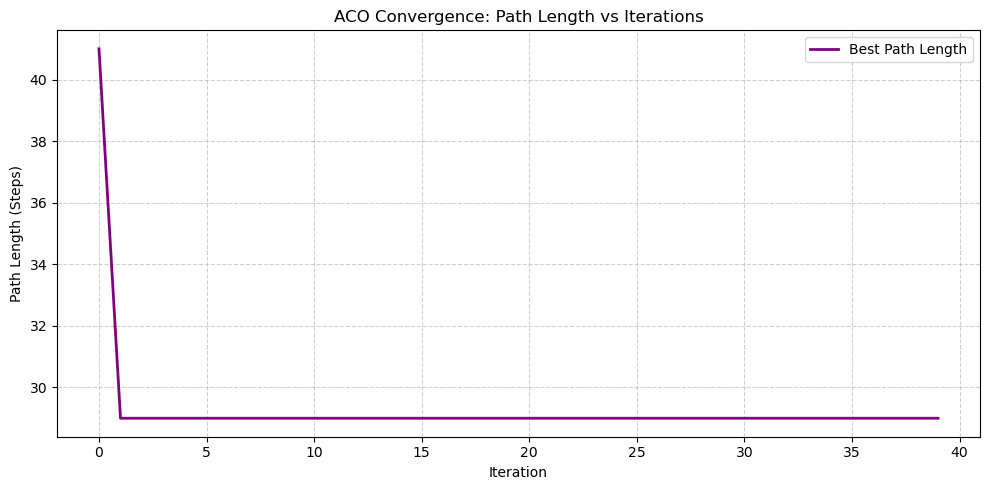

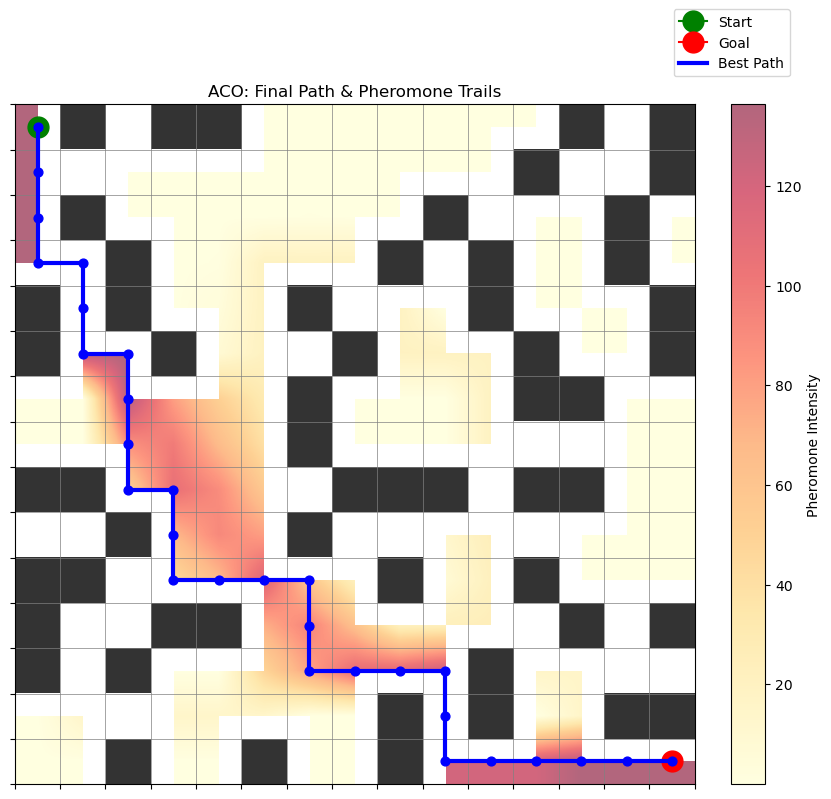

In [4]:
def solve_ant_colony(env, n_ants=20, n_iterations=50, decay=0.9, alpha=1.0, beta=2.0, q=100):
    """
    Ant Colony Optimization (ACO) Algorithm.
    
    Parameters:
    - env: PathPlanningEnv instance
    - n_ants: Number of ants per iteration
    - n_iterations: Number of iterations to run
    - decay: Pheromone evaporation rate (0-1), e.g., 0.9 means 10% evaporates
    - alpha: Importance of pheromone trail
    - beta: Importance of heuristic information (1/distance)
    - q: Pheromone deposit factor
    
    Returns:
    - best_path: The shortest path found
    - all_paths_history: List of best path lengths per iteration (for plotting convergence)
    - final_pheromones: The pheromone matrix at the end
    """
    width, height = env.width, env.height
    start = env.start
    goal = env.end
    
    if not start or not goal:
        raise ValueError("Start or Goal not defined")

    # Initialize Pheromone Matrix (tau)
    # Dimensions: (height, width), same as grid
    tau = np.ones((height, width)) * 0.1 
    
    # Heuristic Matrix (eta) = 1 / distance to goal
    # We pre-calculate this to speed up
    eta = np.zeros((height, width))
    for y in range(height):
        for x in range(width):
            dist = abs(x - goal[0]) + abs(y - goal[1])
            eta[y, x] = 1.0 / (dist + 0.1) # +0.1 to avoid division by zero at goal

    best_path = None
    best_length = float('inf')
    history = []

    print(f"🐜 Starting Ant Colony Optimization ({n_iterations} iterations, {n_ants} ants)...")

    for iteration in range(n_iterations):
        paths = []
        lengths = []
        
        # --- 1. Each Ant Constructs a Path ---
        for _ in range(n_ants):
            current = start
            path = [current]
            visited = set([current])
            dead_end = False
            
            while current != goal:
                neighbors = env.get_neighbors(current)
                # Filter out already visited nodes in current path to avoid loops
                valid_neighbors = [n for n in neighbors if n not in visited]
                
                if not valid_neighbors:
                    dead_end = True
                    break
                
                # Calculate probabilities for each neighbor
                probs = []
                for nx, ny in valid_neighbors:
                    # Pheromone level
                    t = tau[ny, nx]
                    # Heuristic value
                    e = eta[ny, nx]
                    
                    # Probability formula: (tau^alpha) * (eta^beta)
                    prob = (t ** alpha) * (e ** beta)
                    probs.append(prob)
                
                # Normalize probabilities
                total_prob = sum(probs)
                probs = [p / total_prob for p in probs]
                
                # Select next node based on probability
                next_node = random.choices(valid_neighbors, weights=probs, k=1)[0]
                
                path.append(next_node)
                visited.add(next_node)
                current = next_node
            
            if not dead_end:
                paths.append(path)
                lengths.append(len(path))
            else:
                # If ant got stuck, ignore or assign huge length
                paths.append(None)
                lengths.append(float('inf'))

        # --- 2. Update Pheromones ---
        
        # Evaporation: Reduce all pheromones
        tau = tau * decay
        
        # Deposit: Add pheromones based on path quality
        for i, path in enumerate(paths):
            if path is not None:
                L = lengths[i]
                # Shorter path -> More pheromone
                delta_tau = q / L
                for x, y in path:
                    tau[y, x] += delta_tau
        
        # --- 3. Record Best Path of this Iteration ---
        if lengths and min(lengths) < best_length:
            best_length = min(lengths)
            best_idx = lengths.index(best_length)
            best_path = paths[best_idx]
            
        history.append(best_length)
        
        if iteration % 10 == 0:
            print(f"Iter {iteration}: Best Length = {best_length}")

    if best_path is None:
        print("❌ ACO failed to find any path.")
    
    return best_path, history, tau

def plot_aco_convergence(history, title="ACO Convergence"):
    """Plot the convergence of the best path length over iterations."""
    plt.figure(figsize=(10, 5))
    plt.plot(history, label='Best Path Length', color='purple', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Path Length (Steps)')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_aco_map(env, path=None, pheromones=None, title="ACO Result"):
    """Visualize the map with the final path and pheromone heatmap."""
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot Grid (Obstacles)
    cmap_obs = mcolors.ListedColormap(['white', 'black'])
    bounds = [0, 1, 2]
    norm = mcolors.BoundaryNorm(bounds, cmap_obs.N)
    ax.imshow(env.grid, cmap=cmap_obs, norm=norm, alpha=0.8)

    # Plot Pheromone Heatmap (Overlay)
    if pheromones is not None:
        # Mask obstacles so they don't show pheromones
        masked_tau = np.ma.masked_where(env.grid == 1, pheromones)
        # Use a colormap like 'YlOrRd' (Yellow-Orange-Red) for pheromones
        im = ax.imshow(masked_tau, cmap='YlOrRd', alpha=0.6, interpolation='bilinear')
        # Add a colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Pheromone Intensity')

    # Plot Start/End
    ax.plot(env.start[0], env.start[1], marker='o', color='green', markersize=15, label='Start', zorder=5)
    ax.plot(env.end[0], env.end[1], marker='o', color='red', markersize=15, label='Goal', zorder=5)

    # Plot Final Path
    if path:
        px, py = zip(*path)
        ax.plot(px, py, color='blue', linewidth=3, label='Best Path', zorder=6)
        ax.scatter(px, py, c='blue', s=40, zorder=6)

    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, env.width, 1))
    ax.set_yticks(np.arange(-0.5, env.height, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.15))
    plt.tight_layout()
    plt.show()

# --- 运行测试 ---

print("\n" + "="*30)
print("Running Ant Colony Optimization...")
print("="*30)

# 创建环境 (稍微小一点，因为ACO计算量比A*大)
env_aco = PathPlanningEnv(width=15, height=15, obstacle_ratio=0.25)

# 运行 ACO
# 参数说明: 
# n_ants=30: 每次迭代30只蚂蚁
# n_iterations=40: 迭代40代
# decay=0.9: 信息素每代挥发10%
# alpha=1, beta=2: 更看重启发式距离(贪心一点)，但也看信息素
aco_path, history, final_tau = solve_ant_colony(
    env_aco, 
    n_ants=30, 
    n_iterations=40, 
    decay=0.85, 
    alpha=1.0, 
    beta=2.5, 
    q=50
)

if aco_path:
    print(f"✅ ACO Found Path! Length: {len(aco_path)}")
    
    # 1. 绘制收敛曲线 (看算法是如何一步步优化的)
    plot_aco_convergence(history, title="ACO Convergence: Path Length vs Iterations")
    
    # 2. 绘制地图 + 信息素热力图 + 最终路径
    plot_aco_map(env_aco, path=aco_path, pheromones=final_tau, title="ACO: Final Path & Pheromone Trails")
else:
    print("❌ ACO failed. Try increasing iterations or ants.")

✅ Solvable map generated on attempt 1
Map Size: 8x8
Start: (0, 0), End: (7, 7), Enemy: (3, 5)
🎮 Starting Minimax Pursuit (Max Depth: 8)...
Step 5: Player at (0, 3), Enemy at (3, 6)
Step 10: Player at (0, 4), Enemy at (3, 6)
Step 15: Player at (0, 3), Enemy at (3, 6)
Step 20: Player at (0, 4), Enemy at (3, 6)
Step 25: Player at (0, 3), Enemy at (3, 6)
Step 30: Player at (0, 4), Enemy at (3, 6)
Step 35: Player at (0, 3), Enemy at (3, 6)
Step 40: Player at (0, 4), Enemy at (3, 6)
Step 45: Player at (0, 3), Enemy at (3, 6)
Step 50: Player at (0, 4), Enemy at (3, 6)
❌ Failed to reach goal (caught or stuck).


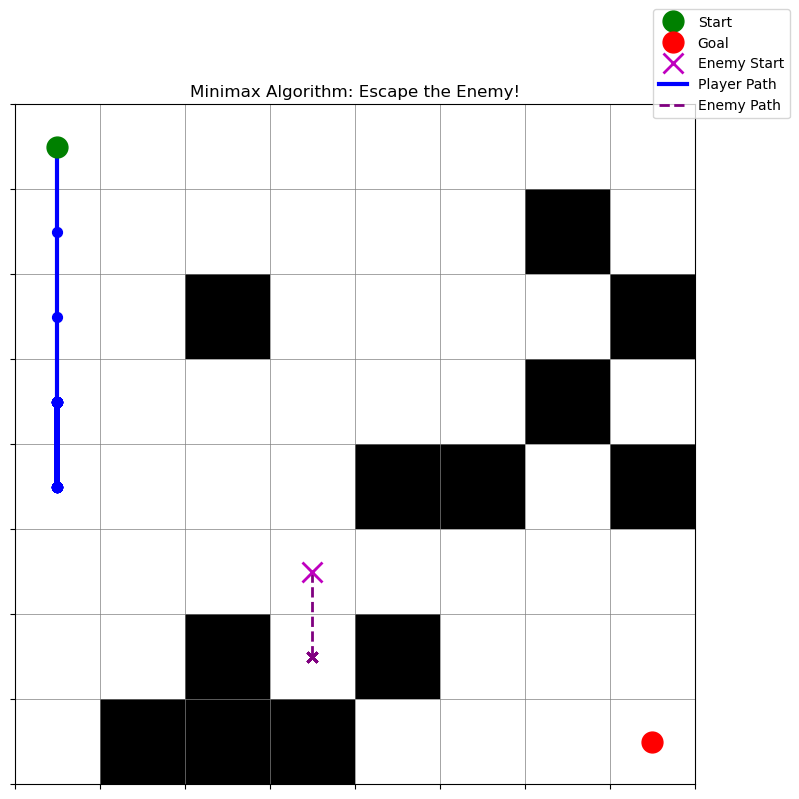

In [7]:
# ==========================================
# 1. 扩展环境：增加一个会移动的敌人
# ==========================================
class PursuitEnv(PathPlanningEnv):
    def __init__(self, width=10, height=10, obstacle_ratio=0.2):
        # 初始化基础地图
        super().__init__(width=width, height=height, obstacle_ratio=obstacle_ratio)
        
        # 设置敌人位置 (随机找一个离起点远一点的空地)
        self.enemy = None
        self._set_enemy()

    def _set_enemy(self):
        """Set enemy position far from start."""
        while True:
            x = np.random.randint(0, self.width)
            y = np.random.randint(0, self.height)
            # 敌人不能在障碍物上，不能是起点，也不能离起点太近
            if self.grid[y, x] == 0 and (x, y) != self.start:
                dist = abs(x - self.start[0]) + abs(y - self.start[1])
                if dist > 3: 
                    self.enemy = (x, y)
                    break
    
    def get_enemy_neighbors(self):
        """Get valid neighbors for the enemy."""
        return self.get_neighbors(self.enemy)

    def is_caught(self, player_pos, enemy_pos):
        """Check if player is caught by enemy."""
        return player_pos == enemy_pos

    def reset_positions(self, player_pos, enemy_pos):
        """Helper to simulate moves without changing original state permanently."""
        # 在实际 Minimax 中，我们通常只传递状态副本，不修改 self
        pass

# ==========================================
# 2. Minimax 算法核心
# ==========================================

def evaluate_state(player_pos, enemy_pos, goal_pos, grid_shape):
    """
    评估函数 (Heuristic Evaluation Function).
    返回一个分数：越高越好。
    - 如果被抓住：负无穷
    - 如果到达终点：正无穷
    - 否则：距离终点的距离 (负值，因为越近越好) + 距离敌人的距离 (正值，越远越好)
    """
    if player_pos == enemy_pos:
        return -float('inf')  # 被抓住，最坏情况
    
    if player_pos == goal_pos:
        return float('inf')   # 到达终点，最好情况
    
    # 曼哈顿距离
    dist_to_goal = abs(player_pos[0] - goal_pos[0]) + abs(player_pos[1] - goal_pos[1])
    dist_to_enemy = abs(player_pos[0] - enemy_pos[0]) + abs(player_pos[1] - enemy_pos[1])
    
    # 权重调整：活着比什么都重要，所以远离敌人的权重高一点
    score = (dist_to_enemy * 2) - dist_to_goal
    return score

def minimax(env, player_pos, enemy_pos, depth, is_maximizing, goal_pos, max_depth=4):
    """
    Minimax Algorithm with Depth Limit.
    
    :param env: PursuitEnv instance (for grid and neighbors)
    :param player_pos: Current player position (x, y)
    :param enemy_pos: Current enemy position (x, y)
    :param depth: Current depth in the tree
    :param is_maximizing: True if it's Player's turn, False if Enemy's turn
    :param goal_pos: Target position
    :param max_depth: Maximum depth to search (to prevent infinite loops)
    :return: (score, best_move)
             - score: Evaluation score of this state
             - best_move: The next position to move to
    """
    
    # 1. 终止条件：达到深度限制 或 游戏结束
    if depth == 0 or player_pos == goal_pos or player_pos == enemy_pos:
        return evaluate_state(player_pos, enemy_pos, goal_pos, env.grid.shape), None

    if is_maximizing:
        # --- Player's Turn (Maximize Score) ---
        best_score = -float('inf')
        best_move = None
        
        # 获取玩家所有可能的移动
        moves = env.get_neighbors(player_pos)
        # 也可以选择不移动 (Stay)，但在追逐游戏中通常必须移动，这里假设必须移动
        
        if not moves:
            return evaluate_state(player_pos, enemy_pos, goal_pos, env.grid.shape), None

        for move in moves:
            # 模拟移动：玩家移动到 move
            # 注意：这里不真正修改 env，只是递归传递新坐标
            score, _ = minimax(env, move, enemy_pos, depth - 1, False, goal_pos, max_depth)
            
            if score > best_score:
                best_score = score
                best_move = move
        
        return best_score, best_move

    else:
        # --- Enemy's Turn (Minimize Player's Score) ---
        best_score = float('inf')
        best_move = None
        
        # 获取敌人所有可能的移动
        moves = env.get_enemy_neighbors()
        # 敌人也会尝试靠近玩家，这里简化为敌人随机或贪婪移动，但在 Minimax 中我们假设敌人也是最优的
        # 敌人的目标是 minimize 玩家的分数 (即抓住玩家或阻挡玩家)
        
        if not moves:
            return evaluate_state(player_pos, enemy_pos, goal_pos, env.grid.shape), None

        for move in moves:
            # 模拟移动：敌人移动到 move
            score, _ = minimax(env, player_pos, move, depth - 1, True, goal_pos, max_depth)
            
            if score < best_score:
                best_score = score
                best_move = move
        
        return best_score, best_move

def solve_minimax_path(env, max_depth=4):
    """
    Generate a full path using Minimax step-by-step.
    Since Minimax is usually for one-step decision, we run it iteratively to form a path.
    """
    current_player = env.start
    current_enemy = env.enemy
    goal = env.end
    path = [current_player]
    enemy_path = [current_enemy]
    
    print(f"🎮 Starting Minimax Pursuit (Max Depth: {max_depth})...")
    
    max_steps = 50  # Safety break
    steps = 0
    
    while current_player != goal and steps < max_steps:
        # 1. Player's Move
        score, next_player_move = minimax(
            env, current_player, current_enemy, 
            depth=max_depth, is_maximizing=True, 
            goal_pos=goal
        )
        
        if next_player_move is None:
            print("❌ Player has no valid moves!")
            break
            
        current_player = next_player_move
        path.append(current_player)
        
        # Check if caught immediately after player moves (e.g. moving into enemy)
        if current_player == current_enemy:
            print("💀 Caught by enemy immediately!")
            break
            
        # 2. Enemy's Move (Simulated optimal response)
        # In a real game, the enemy would actually move. Here we simulate its optimal counter-move.
        _, next_enemy_move = minimax(
            env, current_player, current_enemy,
            depth=max_depth, is_maximizing=False,
            goal_pos=goal
        )
        
        if next_enemy_move:
            current_enemy = next_enemy_move
            enemy_path.append(current_enemy)
        
        # Check if caught after enemy moves
        if current_player == current_enemy:
            print("💀 Caught by enemy after their move!")
            break
            
        steps += 1
        if steps % 5 == 0:
            print(f"Step {steps}: Player at {current_player}, Enemy at {current_enemy}")

    if current_player == goal:
        print("✅ Goal reached safely!")
        return path, enemy_path
    else:
        print("❌ Failed to reach goal (caught or stuck).")
        return path, enemy_path

# ==========================================
# 3. 可视化
# ==========================================

def plot_pursuit_map(env, player_path, enemy_path, title="Minimax Pursuit"):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot Grid
    cmap = mcolors.ListedColormap(['white', 'black'])
    bounds = [0, 1, 2]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    ax.imshow(env.grid, cmap=cmap, norm=norm)

    # Plot Start/End
    ax.plot(env.start[0], env.start[1], 'go', markersize=15, label='Start', zorder=5)
    ax.plot(env.end[0], env.end[1], 'ro', markersize=15, label='Goal', zorder=5)
    
    # Plot Enemy Start
    ax.plot(env.enemy[0], env.enemy[1], 'mx', markersize=15, markeredgewidth=2, label='Enemy Start', zorder=5)

    # Plot Player Path
    if player_path:
        px, py = zip(*player_path)
        ax.plot(px, py, color='blue', linewidth=3, label='Player Path', zorder=4)
        ax.scatter(px, py, c='blue', s=50, zorder=4)

    # Plot Enemy Path
    if enemy_path:
        ex, ey = zip(*enemy_path)
        ax.plot(ex, ey, color='purple', linestyle='--', linewidth=2, label='Enemy Path', zorder=3)
        ax.scatter(ex, ey, c='purple', s=50, marker='x', zorder=3)

    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, env.width, 1))
    ax.set_yticks(np.arange(-0.5, env.height, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(which='both', color='gray', linestyle='-', linewidth=0.5)
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1.15))
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 运行测试
# ==========================================

if __name__ == "__main__":
    # 固定种子以保证复现
    np.random.seed(42)
    
    # 创建带敌人的环境 (地图小一点，方便 Minimax 搜索)
    # 注意：Minimax 复杂度是指数级的 O(b^d)，地图太大或深度太深会非常慢
    env_game = PursuitEnv(width=8, height=8, obstacle_ratio=0.2)
    
    print(f"Map Size: {env_game.width}x{env_game.height}")
    print(f"Start: {env_game.start}, End: {env_game.end}, Enemy: {env_game.enemy}")
    
    # 运行 Minimax
    # max_depth=4 意味着向前看 4 步 (玩家 - 敌人 - 玩家 - 敌人)
    p_path, e_path = solve_minimax_path(env_game, max_depth=8)
    
    # 绘图
    if p_path:
        plot_pursuit_map(env_game, p_path, e_path, title=f"Minimax Algorithm: Escape the Enemy!")